In [2]:
# All the tools we need for EDA
import pandas as pd
from google.cloud import bigquery
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Connect to BigQuery
client = bigquery.Client(project="nyc-taxi-intelligence")

print("Connected to BigQuery.")
print("Ready to query 48.7M rows.")

Matplotlib is building the font cache; this may take a moment.


Connected to BigQuery.
Ready to query 48.7M rows.


In [3]:
# Pull a sample of 10 rows to see what the raw data looks like
query = """
    SELECT *
    FROM `nyc-taxi-intelligence.raw.raw_taxi_trips`
    LIMIT 10
"""

sample = client.query(query).to_dataframe()
sample

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_date
0,2,2025-02-28 23:57:18+00:00,2025-02-28 23:58:54+00:00,1.0,0.51,1.0,N,68,68,1,...,1.0,0.5,2.03,0.0,1.0,12.18,2.5,0.0,0.75,2025-02-28
1,2,2025-02-28 23:58:42+00:00,2025-03-01 00:02:23+00:00,3.0,0.83,1.0,N,170,107,1,...,1.0,0.5,1.00,0.0,1.0,12.55,2.5,0.0,0.75,2025-02-28
2,2,2025-02-28 23:52:26+00:00,2025-02-28 23:57:13+00:00,1.0,0.92,1.0,N,142,230,1,...,1.0,0.5,2.59,0.0,1.0,15.54,2.5,0.0,0.75,2025-02-28
3,2,2025-02-28 23:59:24+00:00,2025-03-01 00:05:32+00:00,1.0,1.47,1.0,N,79,186,1,...,1.0,0.5,2.87,0.0,1.0,17.22,2.5,0.0,0.75,2025-02-28
4,2,2025-02-28 22:40:35+00:00,2025-02-28 22:47:22+00:00,1.0,1.01,1.0,N,239,239,1,...,1.0,0.5,2.72,0.0,1.0,16.32,2.5,0.0,0.00,2025-02-28
5,2,2025-02-28 23:03:25+00:00,2025-02-28 23:12:00+00:00,1.0,1.42,1.0,N,163,68,1,...,1.0,0.5,3.15,0.0,1.0,18.90,2.5,0.0,0.75,2025-02-28
6,2,2025-02-28 23:43:49+00:00,2025-02-28 23:52:11+00:00,1.0,1.66,1.0,N,236,238,1,...,1.0,0.5,2.00,0.0,1.0,17.70,2.5,0.0,0.00,2025-02-28
7,2,2025-02-28 23:59:22+00:00,2025-03-01 00:09:36+00:00,2.0,1.54,1.0,N,249,234,1,...,1.0,0.5,3.29,0.0,1.0,19.74,2.5,0.0,0.75,2025-02-28
8,2,2025-02-28 23:35:43+00:00,2025-02-28 23:46:43+00:00,1.0,1.58,1.0,N,100,90,1,...,1.0,0.5,3.29,0.0,1.0,19.74,2.5,0.0,0.75,2025-02-28
9,2,2025-02-28 23:58:39+00:00,2025-03-01 00:07:13+00:00,1.0,1.92,1.0,N,230,239,1,...,1.0,0.5,3.43,0.0,1.0,20.58,2.5,0.0,0.75,2025-02-28


In [4]:
# Count nulls in every column across the entire dataset
query = """
    SELECT
        COUNTIF(VendorID IS NULL)               AS null_VendorID,
        COUNTIF(tpep_pickup_datetime IS NULL)   AS null_pickup,
        COUNTIF(tpep_dropoff_datetime IS NULL)  AS null_dropoff,
        COUNTIF(passenger_count IS NULL)        AS null_passengers,
        COUNTIF(trip_distance IS NULL)          AS null_distance,
        COUNTIF(fare_amount IS NULL)            AS null_fare,
        COUNTIF(tip_amount IS NULL)             AS null_tip,
        COUNTIF(total_amount IS NULL)           AS null_total,
        COUNTIF(PULocationID IS NULL)           AS null_pickup_zone,
        COUNTIF(DOLocationID IS NULL)           AS null_dropoff_zone,
        COUNTIF(Airport_fee IS NULL)            AS null_airport_fee,
        COUNTIF(cbd_congestion_fee IS NULL)     AS null_cbd_fee,
        COUNT(*)                                AS total_rows
    FROM `nyc-taxi-intelligence.raw.raw_taxi_trips`
"""

nulls = client.query(query).to_dataframe()
nulls.T  # .T = transpose — shows rows as columns so it's easier to read

,0
null_VendorID,0
null_pickup,0
null_dropoff,0
null_passengers,11611894
null_distance,0
null_fare,0
null_tip,0
null_total,0
null_pickup_zone,0
null_dropoff_zone,0


In [5]:
# Which vendor is responsible for all the nulls?
query = """
    SELECT
        VendorID,
        COUNT(*)                                    AS total_trips,
        COUNTIF(passenger_count IS NULL)            AS null_passengers,
        COUNTIF(Airport_fee IS NULL)                AS null_airport_fee,
        ROUND(COUNTIF(passenger_count IS NULL) * 100.0 / COUNT(*), 1) AS pct_null
    FROM `nyc-taxi-intelligence.raw.raw_taxi_trips`
    GROUP BY VendorID
    ORDER BY VendorID
"""

vendor_nulls = client.query(query).to_dataframe()
vendor_nulls

,VendorID,total_trips,null_passengers,null_airport_fee,pct_null
0,1,9586873,1579612,1579612,16.5
1,2,38575846,10008300,10008300,25.9
2,6,23982,23982,23982,100.0
3,7,535901,0,0,0.0


In [6]:
query = """
    SELECT
        MIN(fare_amount)                               AS min_fare,
        APPROX_QUANTILES(fare_amount, 100)[OFFSET(25)] AS p25,
        APPROX_QUANTILES(fare_amount, 100)[OFFSET(50)] AS median,
        APPROX_QUANTILES(fare_amount, 100)[OFFSET(75)] AS p75,
        APPROX_QUANTILES(fare_amount, 100)[OFFSET(95)] AS p95,
        APPROX_QUANTILES(fare_amount, 100)[OFFSET(99)] AS p99,
        MAX(fare_amount)                               AS max_fare,
        AVG(fare_amount)                               AS avg_fare,
        COUNTIF(fare_amount <= 0)                      AS zero_or_negative_fares,
        COUNT(*)                                       AS total
    FROM `nyc-taxi-intelligence.raw.raw_taxi_trips`
"""

fares = client.query(query).to_dataframe()
fares.T

,0
min_fare,-1807.6
p25,8.6
median,13.58
p75,22.6
p95,57.6
p99,79.75
max_fare,863372.12
avg_fare,18.419376
zero_or_negative_fares,2870234
total,48722602


In [8]:
query = """
    SELECT
        MIN(trip_distance)                               AS min_dist,
        APPROX_QUANTILES(trip_distance, 100)[OFFSET(25)] AS p25,
        APPROX_QUANTILES(trip_distance, 100)[OFFSET(50)] AS median,
        APPROX_QUANTILES(trip_distance, 100)[OFFSET(75)] AS p75,
        APPROX_QUANTILES(trip_distance, 100)[OFFSET(95)] AS p95,
        MAX(trip_distance)                               AS max_dist,
        COUNTIF(trip_distance <= 0)                      AS zero_or_negative_dist,
        COUNTIF(trip_distance > 100)                     AS over_100_miles
    FROM `nyc-taxi-intelligence.raw.raw_taxi_trips`
"""

distances = client.query(query).to_dataframe()
distances.T

,0
min_dist,0.0
p25,1.04
median,1.85
p75,3.7
p95,12.77
max_dist,397994.37
zero_or_negative_dist,1402958
over_100_miles,2870


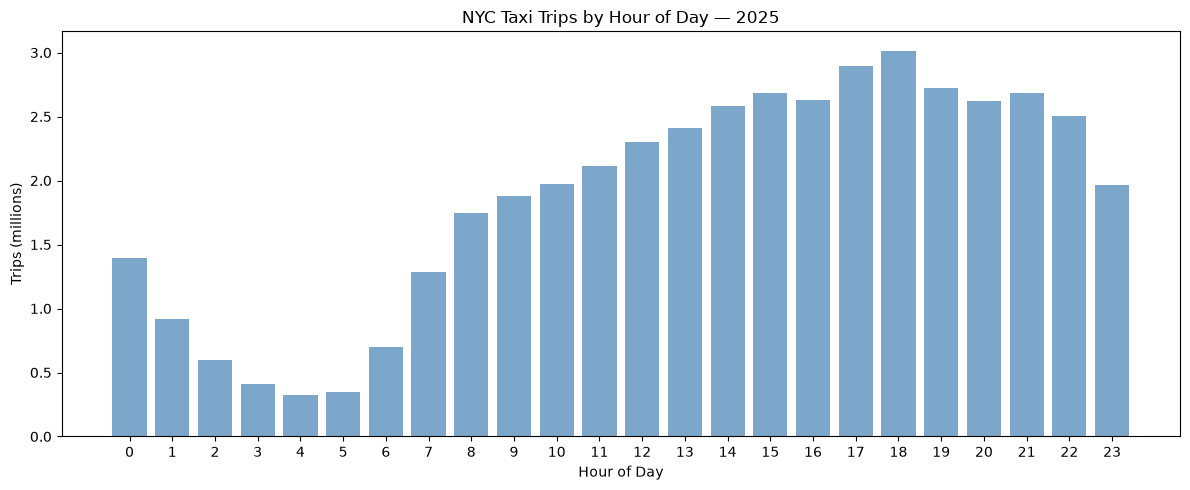

,hour_of_day,total_trips,avg_fare
0,0,1395687,20.84
1,1,918303,19.18
2,2,600915,18.01
3,3,407714,18.70
4,4,322690,23.33
5,5,346268,26.02
6,6,695579,22.69
7,7,1288142,20.32
8,8,1745839,19.42
9,9,1878638,19.01


In [9]:
query = """
    SELECT
        EXTRACT(HOUR FROM tpep_pickup_datetime)     AS hour_of_day,
        COUNT(*)                                    AS total_trips,
        ROUND(AVG(fare_amount), 2)                  AS avg_fare
    FROM `nyc-taxi-intelligence.raw.raw_taxi_trips`
    WHERE fare_amount > 0 AND trip_distance > 0
    GROUP BY hour_of_day
    ORDER BY hour_of_day
"""

hourly = client.query(query).to_dataframe()

# Plot it
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(hourly["hour_of_day"], hourly["total_trips"] / 1_000_000,
        color="steelblue", alpha=0.7)
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Trips (millions)")
ax1.set_title("NYC Taxi Trips by Hour of Day — 2025")
ax1.set_xticks(range(24))

plt.tight_layout()
plt.show()

hourly


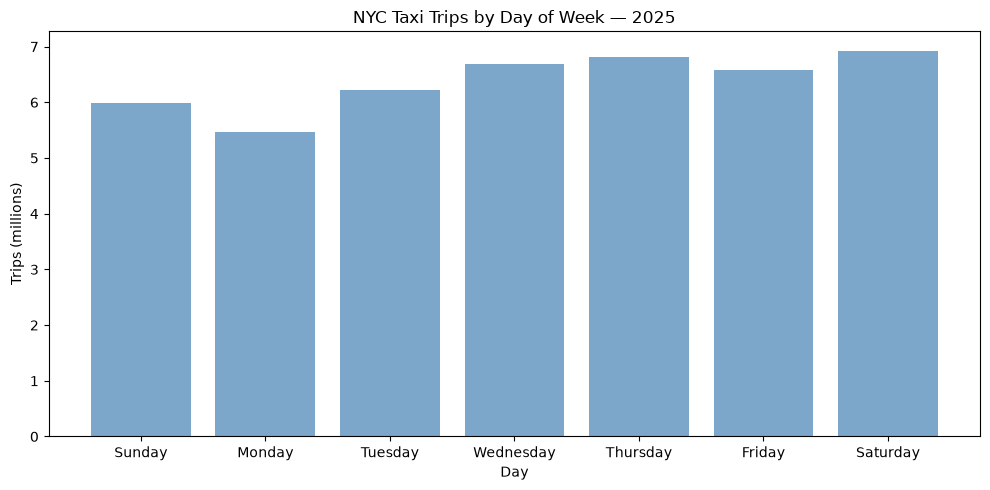

,day_name,day_num,total_trips,avg_fare
0,Sunday,1,5987304,20.85
1,Monday,2,5474855,20.69
2,Tuesday,3,6226792,19.74
3,Wednesday,4,6694881,19.79
4,Thursday,5,6819493,20.16
5,Friday,6,6571598,19.96
6,Saturday,7,6927597,19.23


In [11]:
query = """
    SELECT
        FORMAT_DATE('%A', DATE(tpep_pickup_datetime)) AS day_name,
        EXTRACT(DAYOFWEEK FROM tpep_pickup_datetime)  AS day_num,
        COUNT(*)                                       AS total_trips,
        ROUND(AVG(fare_amount), 2)                     AS avg_fare
    FROM `nyc-taxi-intelligence.raw.raw_taxi_trips`
    WHERE fare_amount > 0 AND trip_distance > 0
    GROUP BY day_name, day_num
    ORDER BY day_num
"""

daily = client.query(query).to_dataframe()

plt.figure(figsize=(10, 5))
plt.bar(daily["day_name"], daily["total_trips"] / 1_000_000, color="steelblue", alpha=0.7)
plt.title("NYC Taxi Trips by Day of Week — 2025")
plt.xlabel("Day")
plt.ylabel("Trips (millions)")
plt.tight_layout()
plt.show()

daily

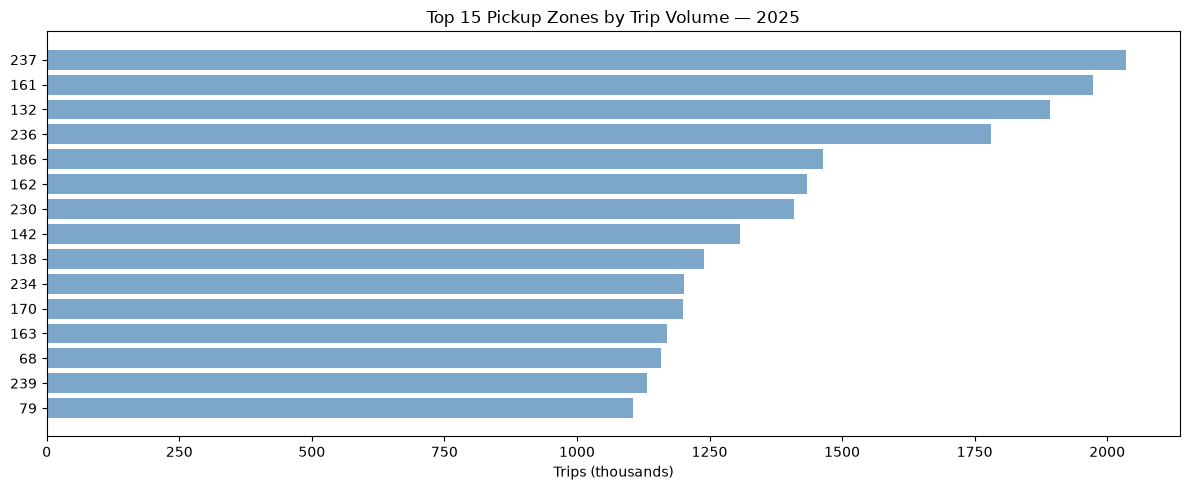

,zone_id,total_trips,avg_fare,avg_distance
0,237,2035569,13.36,2.63
1,161,1973846,17.02,2.99
2,132,1892958,63.56,15.53
3,236,1780861,13.88,2.99
4,186,1463609,17.14,2.74
5,162,1434388,16.13,3.20
6,230,1408587,19.41,3.44
7,142,1307252,14.70,3.00
8,138,1239905,45.52,9.67
9,234,1202529,15.19,3.29


In [12]:
query = """
    SELECT
        PULocationID                AS zone_id,
        COUNT(*)                    AS total_trips,
        ROUND(AVG(fare_amount), 2)  AS avg_fare,
        ROUND(AVG(trip_distance), 2) AS avg_distance
    FROM `nyc-taxi-intelligence.raw.raw_taxi_trips`
    WHERE fare_amount > 0 AND trip_distance > 0
    GROUP BY zone_id
    ORDER BY total_trips DESC
    LIMIT 15
"""

top_zones = client.query(query).to_dataframe()

plt.figure(figsize=(12, 5))
plt.barh(top_zones["zone_id"].astype(str), top_zones["total_trips"] / 1_000,
         color="steelblue", alpha=0.7)
plt.xlabel("Trips (thousands)")
plt.title("Top 15 Pickup Zones by Trip Volume — 2025")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_zones

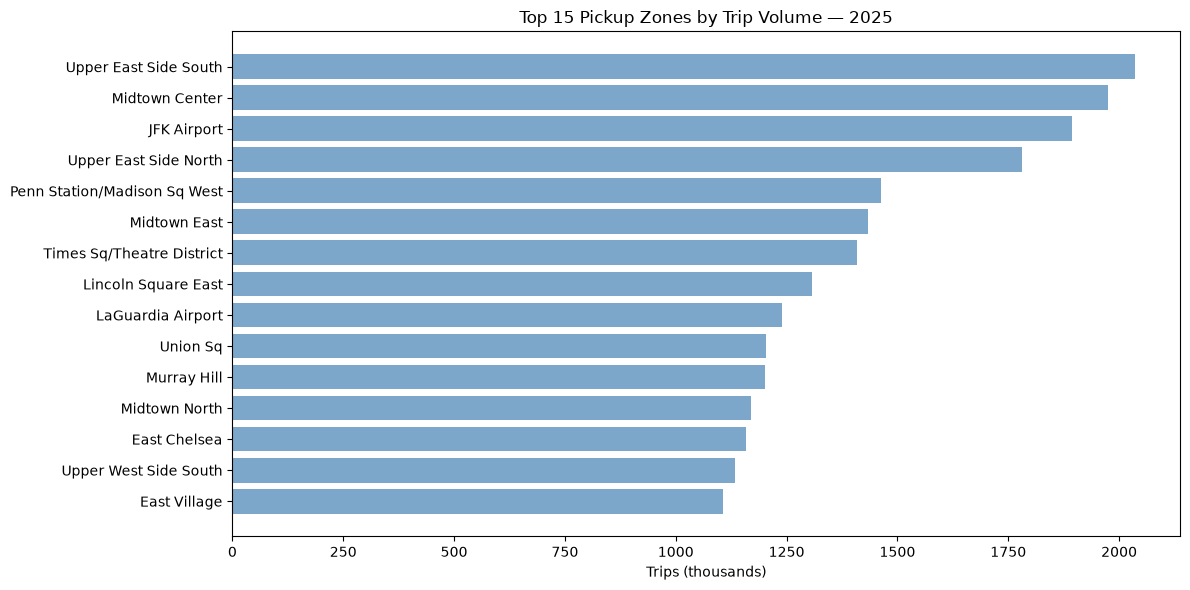

,zone_id,zone_name,borough,total_trips,avg_fare,avg_distance
0,237,Upper East Side South,Manhattan,2035569,13.36,2.63
1,161,Midtown Center,Manhattan,1973846,17.02,2.99
2,132,JFK Airport,Queens,1892958,63.56,15.53
3,236,Upper East Side North,Manhattan,1780861,13.88,2.99
4,186,Penn Station/Madison Sq West,Manhattan,1463609,17.14,2.74
5,162,Midtown East,Manhattan,1434388,16.13,3.20
6,230,Times Sq/Theatre District,Manhattan,1408587,19.41,3.44
7,142,Lincoln Square East,Manhattan,1307252,14.70,3.00
8,138,LaGuardia Airport,Queens,1239905,45.52,9.67
9,234,Union Sq,Manhattan,1202529,15.19,3.29


In [13]:
query = """
    SELECT
        t.PULocationID              AS zone_id,
        z.Zone                      AS zone_name,
        z.Borough                   AS borough,
        COUNT(*)                    AS total_trips,
        ROUND(AVG(t.fare_amount), 2) AS avg_fare,
        ROUND(AVG(t.trip_distance), 2) AS avg_distance
    FROM `nyc-taxi-intelligence.raw.raw_taxi_trips` t
    LEFT JOIN `nyc-taxi-intelligence.raw.raw_zone_lookup` z
        ON t.PULocationID = z.LocationID
    WHERE t.fare_amount > 0 AND t.trip_distance > 0
    GROUP BY zone_id, zone_name, borough
    ORDER BY total_trips DESC
    LIMIT 15
"""

top_zones_named = client.query(query).to_dataframe()

plt.figure(figsize=(12, 6))
plt.barh(top_zones_named["zone_name"], top_zones_named["total_trips"] / 1_000,
         color="steelblue", alpha=0.7)
plt.xlabel("Trips (thousands)")
plt.title("Top 15 Pickup Zones by Trip Volume — 2025")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_zones_named

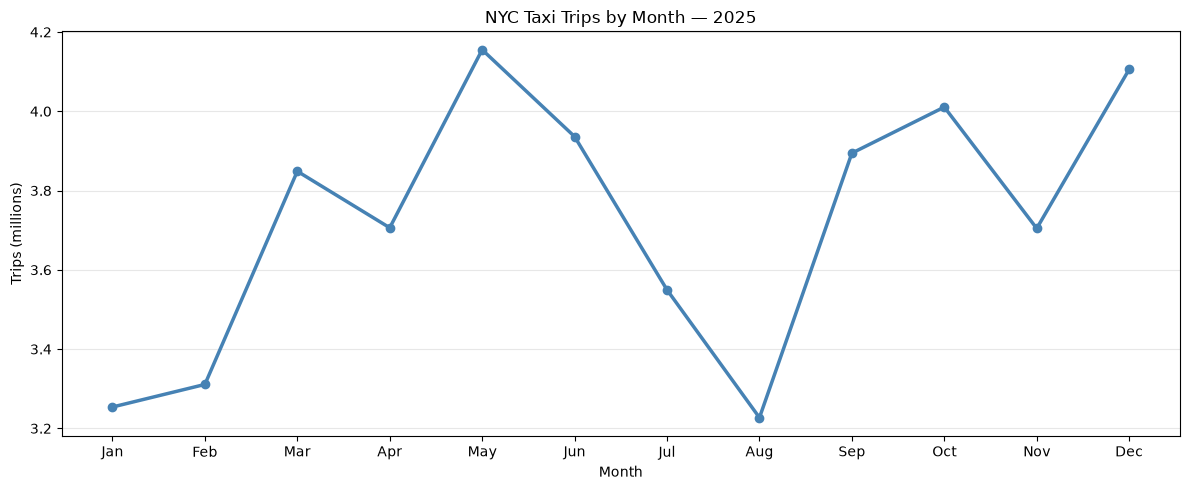

,month_num,month_name,total_trips,avg_fare
0,1,Jan,3253878,18.22
1,2,Feb,3310812,18.07
2,3,Mar,3848647,19.16
3,4,Apr,3706122,19.29
4,5,May,4155275,20.33
5,6,Jun,3936119,20.77
6,7,Jul,3549433,20.36
7,8,Aug,3227039,20.19
8,9,Sep,3894383,20.96
9,10,Oct,4010605,20.24


In [14]:
query = """
    SELECT
        EXTRACT(MONTH FROM tpep_pickup_datetime)     AS month_num,
        FORMAT_DATE('%b', DATE(tpep_pickup_datetime)) AS month_name,
        COUNT(*)                                      AS total_trips,
        ROUND(AVG(fare_amount), 2)                    AS avg_fare
    FROM `nyc-taxi-intelligence.raw.raw_taxi_trips`
    WHERE fare_amount > 0 AND trip_distance > 0
    GROUP BY month_num, month_name
    ORDER BY month_num
"""

monthly = client.query(query).to_dataframe()

plt.figure(figsize=(12, 5))
plt.plot(monthly["month_name"], monthly["total_trips"] / 1_000_000,
         marker="o", linewidth=2.5, color="steelblue")
plt.title("NYC Taxi Trips by Month — 2025")
plt.xlabel("Month")
plt.ylabel("Trips (millions)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

monthly